# Notebook 4: Photon Statistics — Zero-Delay Correlations of Quantum Light

## What are we exploring?

The second-order coherence function $g^{(2)}(0)$ is a **central zero-delay
photon-correlation observable** in quantum optics. It classifies photon
statistics into three regimes:

| Regime | g²(0) | Statistics | Example |
|--------|-------|-----------| --------|
| Anti-bunching | < 1 | Sub-Poissonian | Fock states |
| Random | = 1 | Poissonian | Coherent states (lasers) |
| Bunching | > 1 | Super-Poissonian | Thermal light, squeezed vacuum |

In this notebook, we bring together all four fundamental quantum states and
compare their photon statistics in one unified analysis.

## Conventions used in this notebook

- Natural units are used for the oscillator algebra: $\hbar=1$.
- `N` is the Hilbert-space dimension, so photon numbers run from `0` to `N-1`.
- `g^{(2)}(0)` is a zero-delay correlation diagnostic, not a complete state classifier.
- Analytic tails and observable convergence are used for truncation checks; never trust `sum(P)` alone.

## Setup: Create All Four States with $\langle n \rangle \approx 3$

In [1]:
from pathlib import Path
import sys

import numpy as np
import matplotlib
%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import qutip

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
elif not (PROJECT_ROOT / "src").exists() and (PROJECT_ROOT.parent / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

SRC_DIR = PROJECT_ROOT / "src"
FIG_DIR = PROJECT_ROOT / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))
from qo_utils import (
    photon_distribution,
    plot_photon_distribution,
    plot_wigner,
    wigner_normalization,
    mean_photon_number,
    photon_variance,
    compute_g2_zero,
    mandel_Q,
    coherent_tail,
    thermal_tail,
    squeezed_vacuum_tail,
    cutoff_from_tail,
    squeezed_wigner_extent,
)

plt.rcParams.update({
    'font.size': 12, 'axes.labelsize': 14, 'axes.titlesize': 16,
    'figure.figsize': (8, 5), 'figure.dpi': 150, 'savefig.dpi': 300,
    'text.usetex': False, 'mathtext.fontset': 'stix', 'font.family': 'STIXGeneral',
})

N = 80  # Required for the matched squeezed state with <n> = 3
a = qutip.destroy(N)

# Target: all states with <n> ~ 3 for fair comparison
n_target = 3

# 1. Fock state |3>
fock_state = qutip.basis(N, n_target)

# 2. Coherent state |alpha=sqrt(3)> -> <n> = 3
coherent_state = qutip.coherent(N, np.sqrt(n_target))

# 3. Squeezed vacuum with <n> = sinh^2(r) ~ 3 -> r = arcsinh(sqrt(3))
r_squeeze = np.arcsinh(np.sqrt(n_target))
assert squeezed_vacuum_tail(N, r_squeeze) < 1e-5, "Increase N for the matched squeezed state"
squeezed_state = qutip.squeeze(N, r_squeeze) * qutip.basis(N, 0)

# 4. Thermal state with n_bar = 3
thermal_state = qutip.thermal_dm(N, n_target)

states = {
    'Fock |3>': fock_state,
    'Coherent': coherent_state,
    'Squeezed': squeezed_state,
    'Thermal': thermal_state,
}

# Verify all have <n> ~ 3
print("=== State Verification ===\n")
for name, state in states.items():
    mn = mean_photon_number(state, a)
    print(f"{name:<15}: <n> = {mn:.3f}")

=== State Verification ===

Fock |3>       : <n> = 3.000
Coherent       : <n> = 3.000
Squeezed       : <n> = 3.000
Thermal        : <n> = 3.000


## THE Master Comparison Table

This table is the central deliverable of the single-mode analysis. All four
states have matched $\langle n \rangle \approx 3$, yet they have completely
different photon statistics.

In [2]:
print("=" * 76)
print("              MASTER COMPARISON: QUANTUM STATES OF LIGHT")
print("=" * 76)
print(f"{'State':<14} {'<n>':>6} {'Dn':>6} {'Dn/<n>':>7} "
      f"{'g2(0)':>8} {'Q':>7} {'Statistics':<14}")
print("-" * 76)

for name, state in states.items():
    mn = mean_photon_number(state, a)
    var = photon_variance(state, a)
    dn = np.sqrt(max(var, 0))
    g2 = compute_g2_zero(state, a)
    Q = mandel_Q(state, a)

    if Q < -0.01:
        stat_type = "Sub-Poisson"
    elif abs(Q) < 0.01:
        stat_type = "Poissonian"
    else:
        stat_type = "Super-Poisson"

    rel = dn/mn if mn > 0 else 0
    print(f"{name:<14} {mn:>6.2f} {dn:>6.2f} {rel:>7.2f} "
          f"{g2:>8.3f} {Q:>7.2f} {stat_type:<14}")

print("=" * 76)

              MASTER COMPARISON: QUANTUM STATES OF LIGHT
State             <n>     Dn  Dn/<n>    g2(0)       Q Statistics    
----------------------------------------------------------------------------
Fock |3>         3.00   0.00    0.00    0.667   -1.00 Sub-Poisson   
Coherent         3.00   1.73    0.58    1.000    0.00 Poissonian    
Squeezed         3.00   4.90    1.63    3.333    7.00 Super-Poisson 
Thermal          3.00   3.46    1.15    2.000    3.00 Super-Poisson 


## 4-Panel Photon Number Distributions

Side-by-side comparison of P(n) for all four state types. Notice the dramatically
different shapes — from a single spike (Fock) to the broad geometric
distribution (thermal).

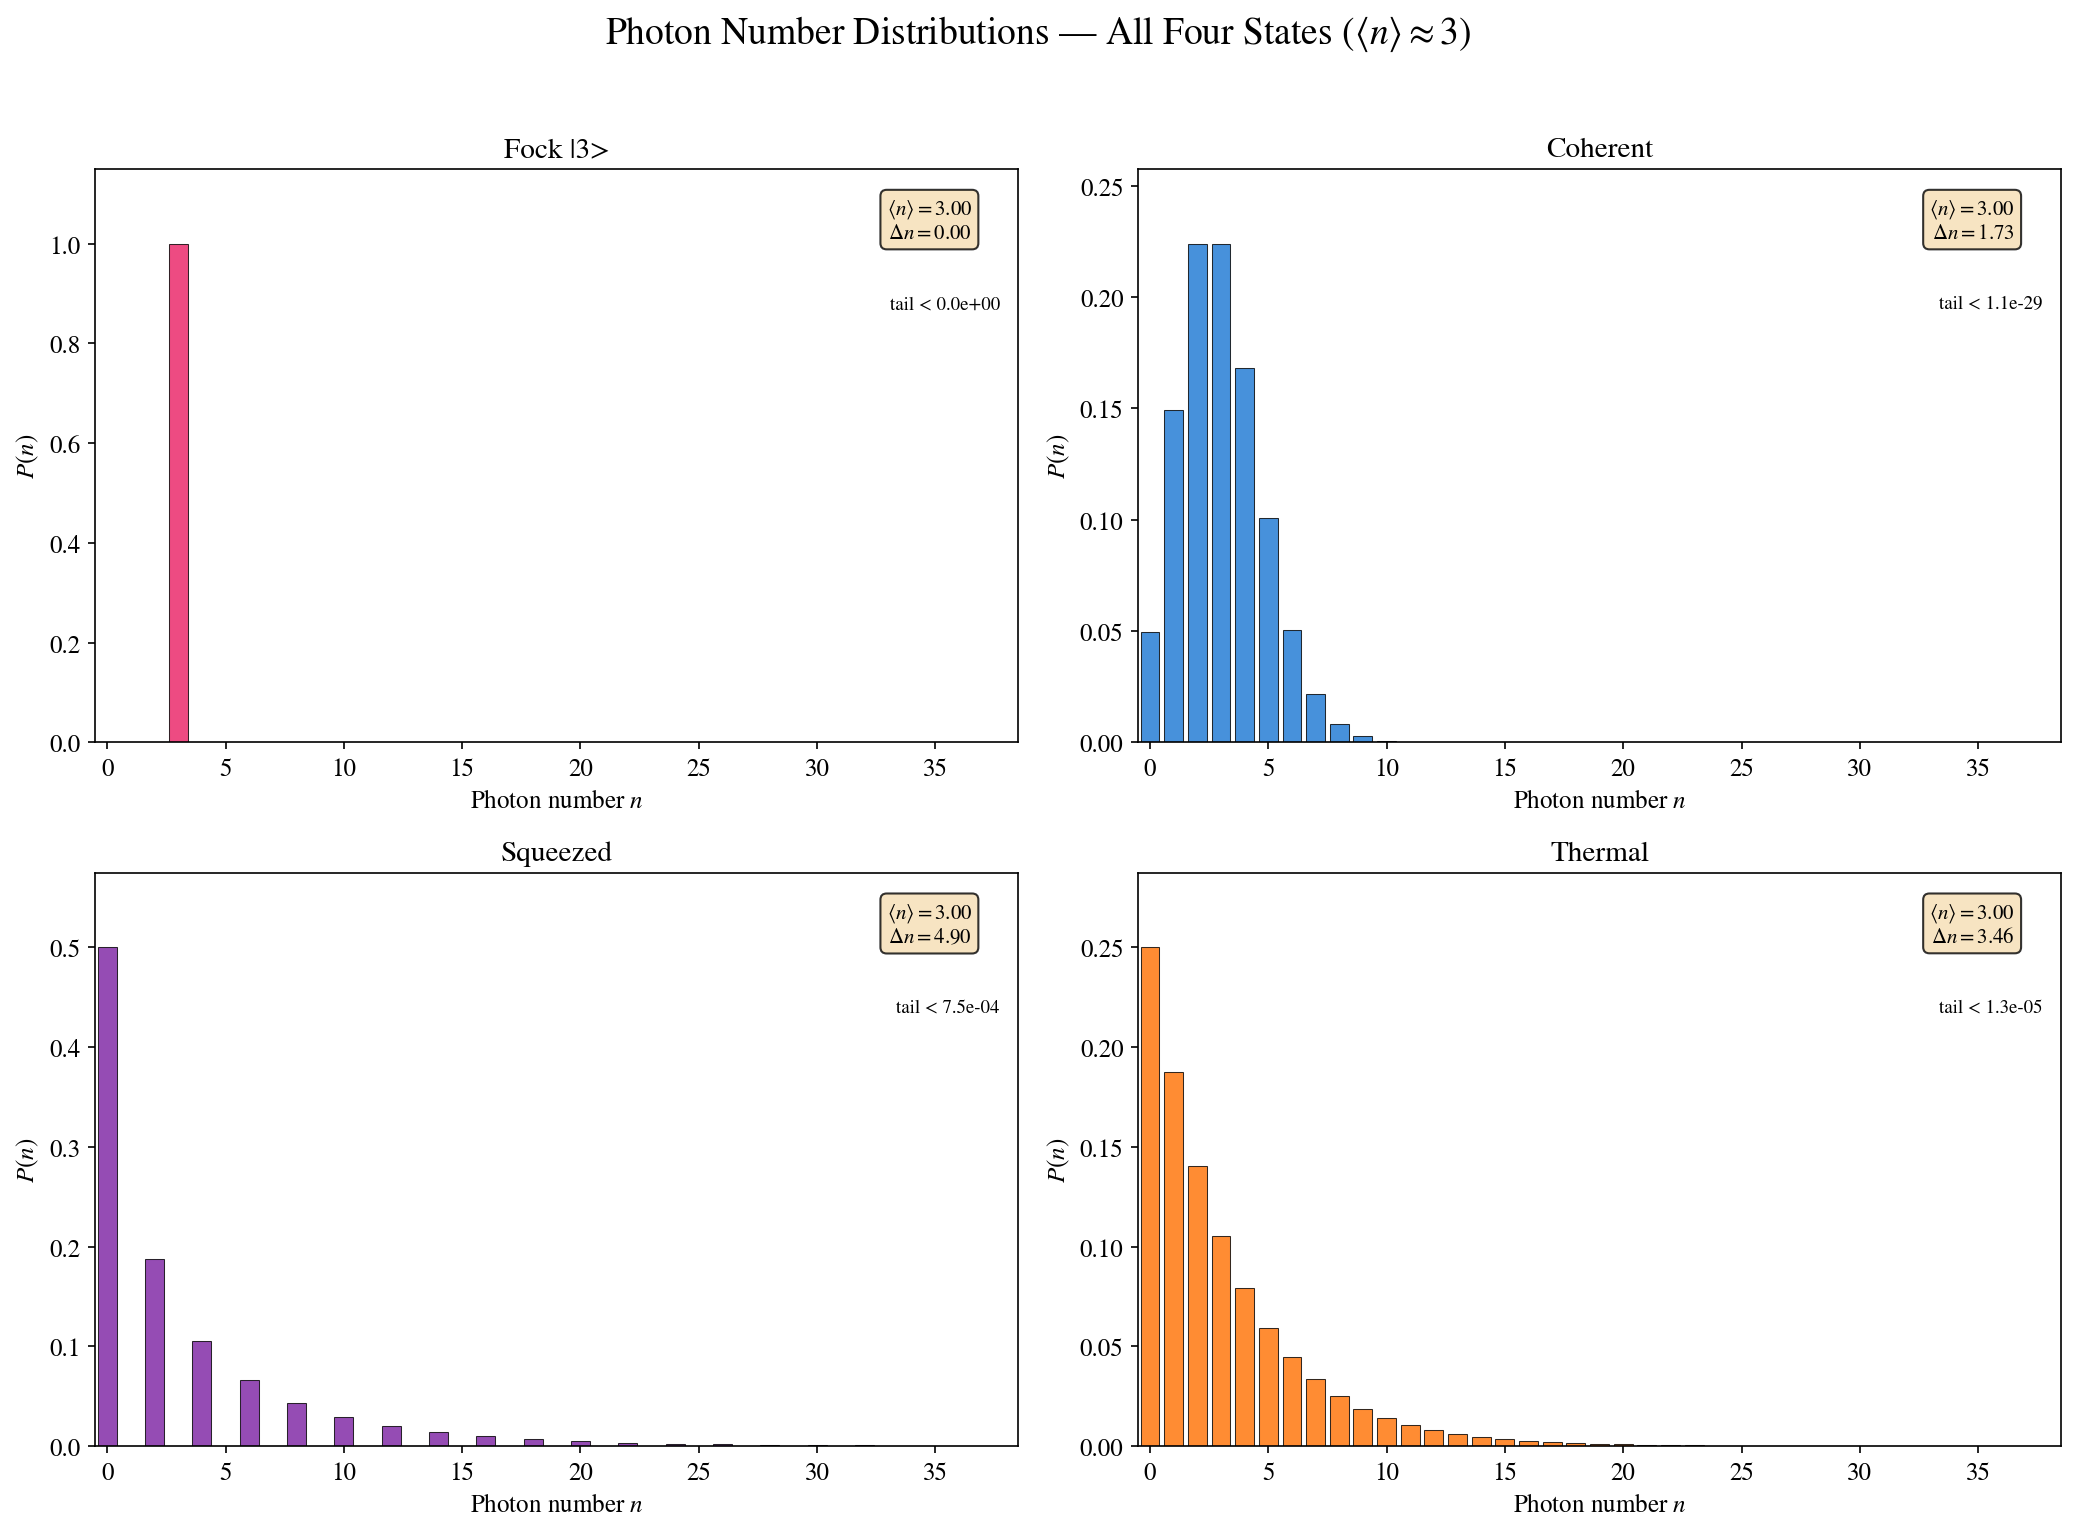

In [3]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
colors = ['#E91E63', '#1976D2', '#7B1FA2', '#FF6F00']

coherent_cutoff = cutoff_from_tail(
    lambda cutoff: coherent_tail(cutoff, np.sqrt(n_target)),
    tolerance=1e-3, start=15,
)
squeezed_cutoff = cutoff_from_tail(
    lambda cutoff: squeezed_vacuum_tail(cutoff, r_squeeze),
    tolerance=1e-3, start=20,
)
thermal_cutoff = cutoff_from_tail(
    lambda cutoff: thermal_tail(cutoff, n_target),
    tolerance=1e-3, start=20,
)
n_plot_common = max(n_target + 3, coherent_cutoff, squeezed_cutoff, thermal_cutoff)

for idx, ((name, state), color) in enumerate(zip(states.items(), colors)):
    ax = axes[idx // 2, idx % 2]
    n_plot = n_plot_common
    if name.startswith('Fock'):
        tail_omitted = 0.0
    elif name.startswith('Coherent'):
        tail_omitted = coherent_tail(n_plot, np.sqrt(n_target))
    elif name.startswith('Squeezed'):
        tail_omitted = squeezed_vacuum_tail(n_plot, r_squeeze)
    else:
        tail_omitted = thermal_tail(n_plot, n_target)

    plot_photon_distribution(state, n_max=n_plot,
                             title=name, ax=ax, color=color, show_stats=True)
    ax.text(0.98, 0.78, f"tail < {tail_omitted:.1e}",
            transform=ax.transAxes, ha='right', va='top', fontsize=9)

plt.suptitle(r'Photon Number Distributions — All Four States ($\langle n \rangle \approx 3$)',
             fontsize=18, y=1.02)
plt.tight_layout()
plt.savefig(FIG_DIR / 'all_states_photon_distributions.png', bbox_inches='tight', dpi=300)
plt.savefig(FIG_DIR / 'all_states_photon_distributions.svg', bbox_inches='tight')
plt.show()

The four distributions show strikingly different shapes:
- **Fock** $|3\rangle$: single spike at $n=3$
- **Coherent**: bell-shaped Poisson centered at $n \approx 3$
- **Squeezed vacuum**: even-number only, peaked at $n=0$, long tail
- **Thermal**: geometrically decreasing from $n=0$

## $g^{(2)}(0)$ Bar Chart: Light Classification

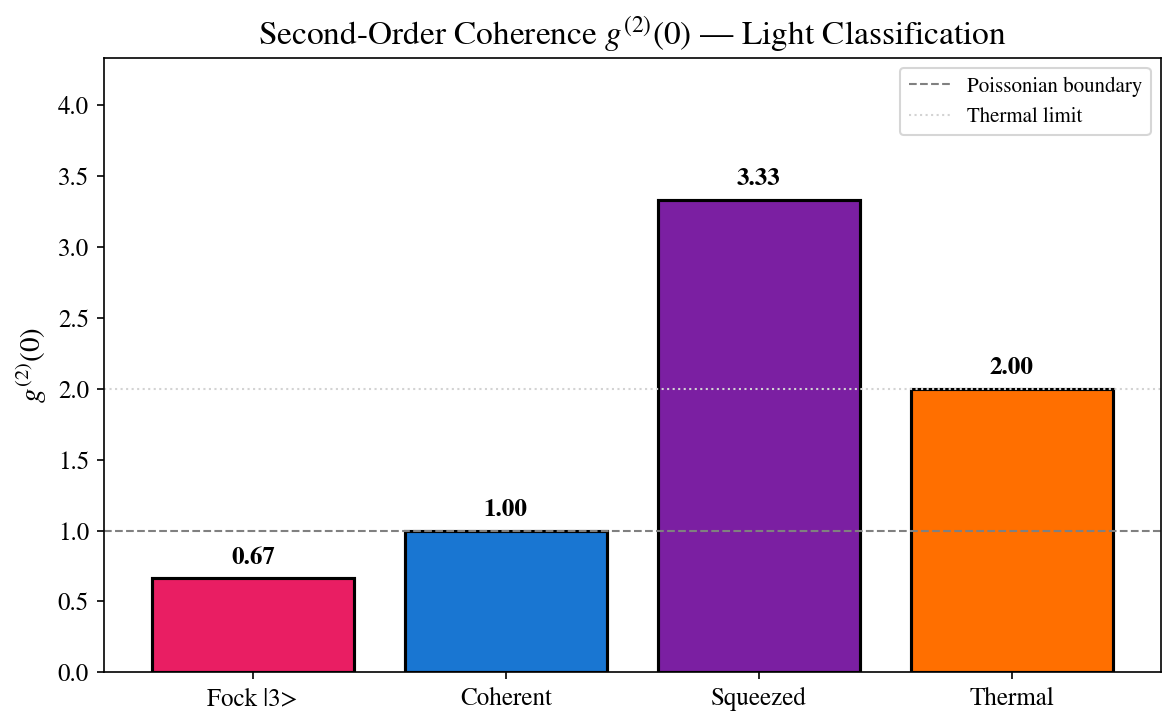

In [4]:
fig, ax = plt.subplots(figsize=(8, 5))

names = list(states.keys())
g2_values = [compute_g2_zero(state, a) for state in states.values()]
bar_colors = ['#E91E63', '#1976D2', '#7B1FA2', '#FF6F00']

bars = ax.bar(names, g2_values, color=bar_colors, edgecolor='black', linewidth=1.5)

ax.axhline(y=1, color='gray', linestyle='--', linewidth=1, label='Poissonian boundary')
ax.axhline(y=2, color='lightgray', linestyle=':', linewidth=1, label='Thermal limit')

for bar, g2 in zip(bars, g2_values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
            f'{g2:.2f}', ha='center', fontsize=12, fontweight='bold')

ax.set_ylabel(r'$g^{(2)}(0)$', fontsize=14)
ax.set_title(r'Second-Order Coherence $g^{(2)}(0)$ — Light Classification', fontsize=16)
ax.legend(fontsize=10)
ax.set_ylim(0, max(g2_values) + 1)

plt.tight_layout()
plt.savefig(FIG_DIR / 'g2_bar_chart_comparison.png', bbox_inches='tight', dpi=300)
plt.savefig(FIG_DIR / 'g2_bar_chart_comparison.svg', bbox_inches='tight')
plt.show()

The bar chart clearly shows the ordering:
Fock ($g^{(2)}(0) < 1$) → Coherent ($= 1$) → Thermal ($= 2$) → Squeezed ($> 3$).

## 4-Panel Wigner Function Comparison

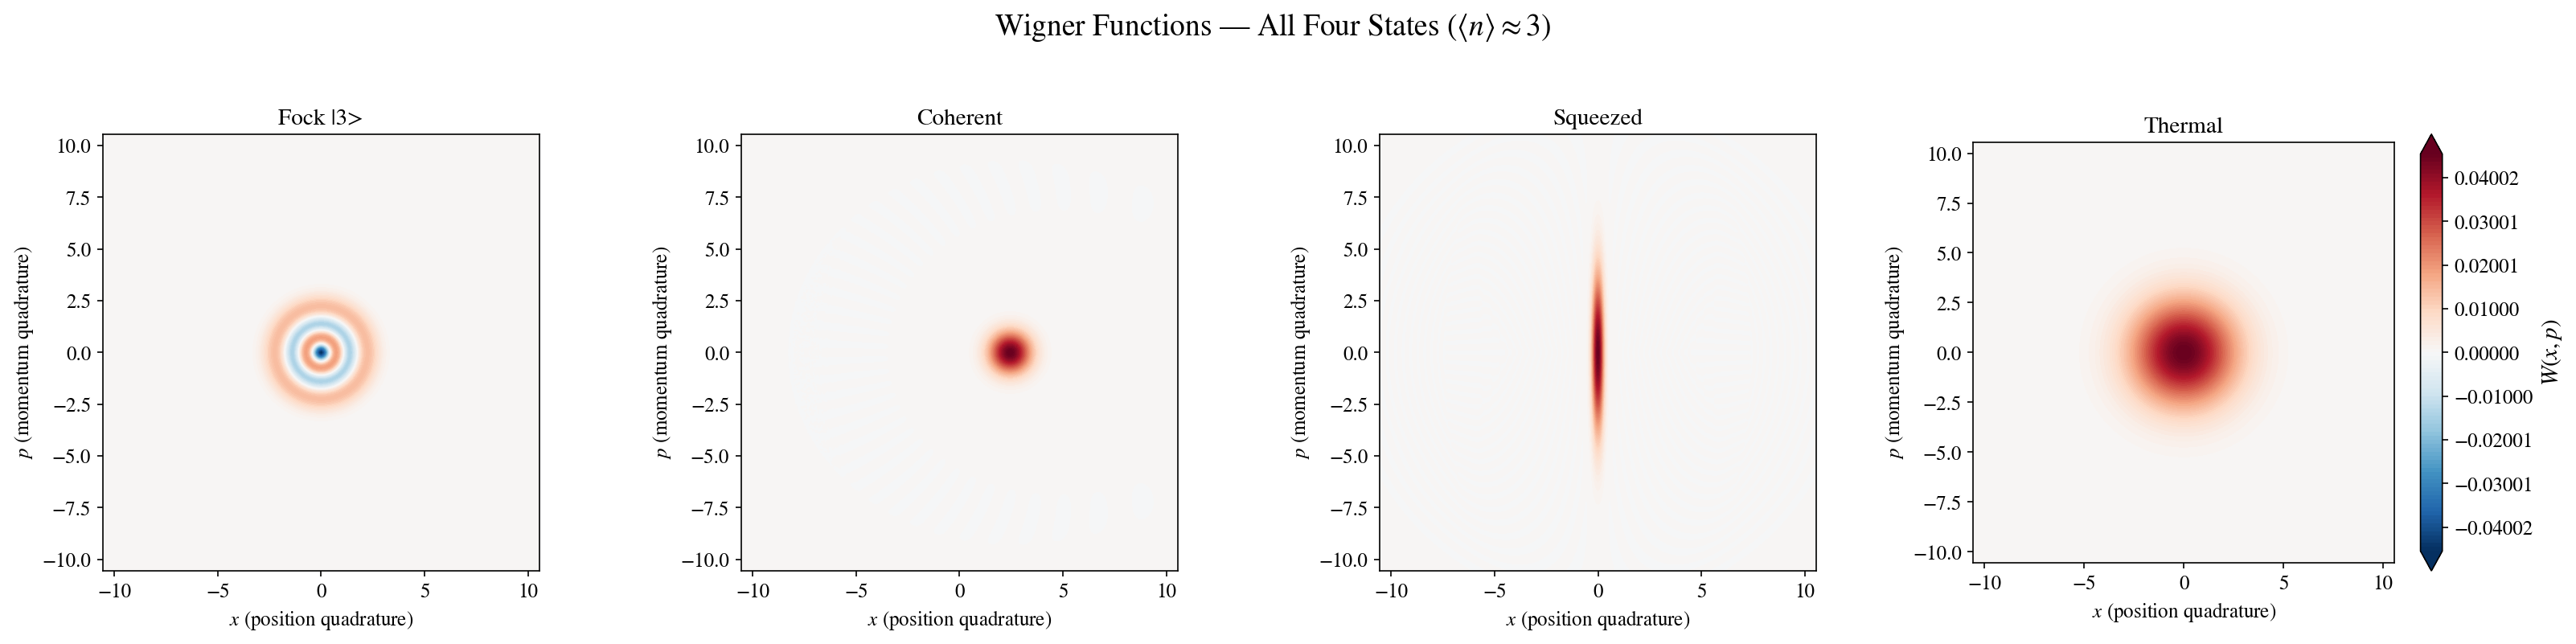

In [5]:
fig, axes = plt.subplots(1, 4, figsize=(22, 5))
extent = squeezed_wigner_extent([r_squeeze], nsigma=4, floor=6.0)
xvec = np.linspace(-extent, extent, 301)

for idx, ((name, state), color) in enumerate(zip(states.items(), colors)):
    _, W = plot_wigner(state, xvec=xvec, title=name, ax=axes[idx],
                       show_colorbar=(idx == 3))
    norm = wigner_normalization(W, xvec, xvec)
    assert np.isclose(norm, 1.0, atol=5e-3), f"Wigner integral for {name} = {norm}"

plt.suptitle(r'Wigner Functions — All Four States ($\langle n \rangle \approx 3$)',
             fontsize=18, y=1.05)
plt.tight_layout()
plt.savefig(FIG_DIR / 'all_states_wigner_comparison.png', bbox_inches='tight', dpi=300)
plt.savefig(FIG_DIR / 'all_states_wigner_comparison.svg', bbox_inches='tight')
plt.show()

## The $g^{(2)}(0)$ Classification of Photon Statistics

The second-order coherence function $g^{(2)}(0)$ provides a **coarse but powerful
classification of zero-delay photon statistics**. It distinguishes three regimes
of photon arrival correlations, but it is not a complete state classifier: many
inequivalent quantum states can share the same $g^{(2)}(0)$, so interpret it
together with photon-number distribution, Wigner function, mean photon number,
and quadrature statistics.

**Anti-bunching** ($g^{(2)}(0) < 1$): Photons tend to arrive alone, never in pairs.
This is a uniquely quantum phenomenon with no classical analog. Fock states achieve
the strongest anti-bunching, with $g^{(2)}(0) = 0$ for $|1\rangle$.

**Poissonian** ($g^{(2)}(0) = 1$): Photons arrive randomly, with no correlation
between arrivals. This is the boundary between quantum and classical light. Coherent
states (laser output) are exactly Poissonian.

**Bunching** ($g^{(2)}(0) > 1$): Photons tend to arrive in groups. Thermal light
gives $g^{(2)}(0) = 2$; squeezed vacuum gives $g^{(2)}(0) > 3$. Note that bunching
can be either classical (thermal) or quantum (squeezed).

This classification, first established experimentally by Hanbury Brown & Twiss (1956),
remains the cornerstone of quantum optics.

## Thermal State: Manual Construction Exercise

Instead of only using QuTiP's `thermal_dm()`, we construct the thermal density
matrix BY HAND from the Bose-Einstein distribution. This deepens understanding
of density matrices and validates the QuTiP function.

In [6]:
def thermal_dm_manual(N, n_bar, normalize=True):
    """
    Manually construct the thermal density matrix from the Bose-Einstein distribution.

    Physics: rho_th = Sum_n P(n)|n><n|
    where P(n) = <n>^n / (1 + <n>)^(n+1)  (Bose-Einstein distribution)
    """
    q = n_bar / (1 + n_bar)
    weights = (1 - q) * q**np.arange(N)
    tail_mass = q**N

    if normalize:
        weights = weights / weights.sum()

    rho = 0 * qutip.ket2dm(qutip.basis(N, 0))
    for n, weight in enumerate(weights):
        rho += weight * qutip.ket2dm(qutip.basis(N, n))

    return rho, tail_mass


# Verification: compare manual vs QuTiP
N_test = 30
n_bar_test = 3.0

rho_manual, tail_mass = thermal_dm_manual(N_test, n_bar_test, normalize=True)
rho_qutip = qutip.thermal_dm(N_test, n_bar_test, method="operator")

# Check they're the same matrix
diff = (rho_manual - rho_qutip).norm()
print(f"||rho_manual - rho_qutip|| = {diff:.2e}")
print(f"Analytic tail beyond N={N_test}: {tail_mass:.3e}")
assert diff < 1e-10, "Normalized manual and QuTiP operator-method thermal states don't match!"

# Check properties
a_test = qutip.destroy(N_test)
print(f"<n> manual  = {qutip.expect(a_test.dag()*a_test, rho_manual):.4f}")
print(f"<n> QuTiP   = {qutip.expect(a_test.dag()*a_test, rho_qutip):.4f}")
print(f"Tr(rho^2) manual = {(rho_manual * rho_manual).tr():.6f}")
print(f"Tr(rho^2) QuTiP  = {(rho_qutip * rho_qutip).tr():.6f}")
print(f"Purity < 1? {(rho_manual * rho_manual).tr() < 1.0}")

print("\n[PASS] Normalized manual thermal state matches QuTiP's operator method!")

||rho_manual - rho_qutip|| = 0.00e+00
Analytic tail beyond N=30: 1.786e-04
<n> manual  = 2.9946
<n> QuTiP   = 2.9946
Tr(rho^2) manual = 0.142908
Tr(rho^2) QuTiP  = 0.142908
Purity < 1? True

[PASS] Normalized manual thermal state matches QuTiP's operator method!


## Mandel $Q/\langle n \rangle$ vs $g^{(2)}(0)$: Universal Relation

The identity $g^{(2)}(0) = 1 + Q/\langle n \rangle$ connects the Mandel Q parameter
to second-order coherence. All states — regardless of type — must fall on this
universal line.

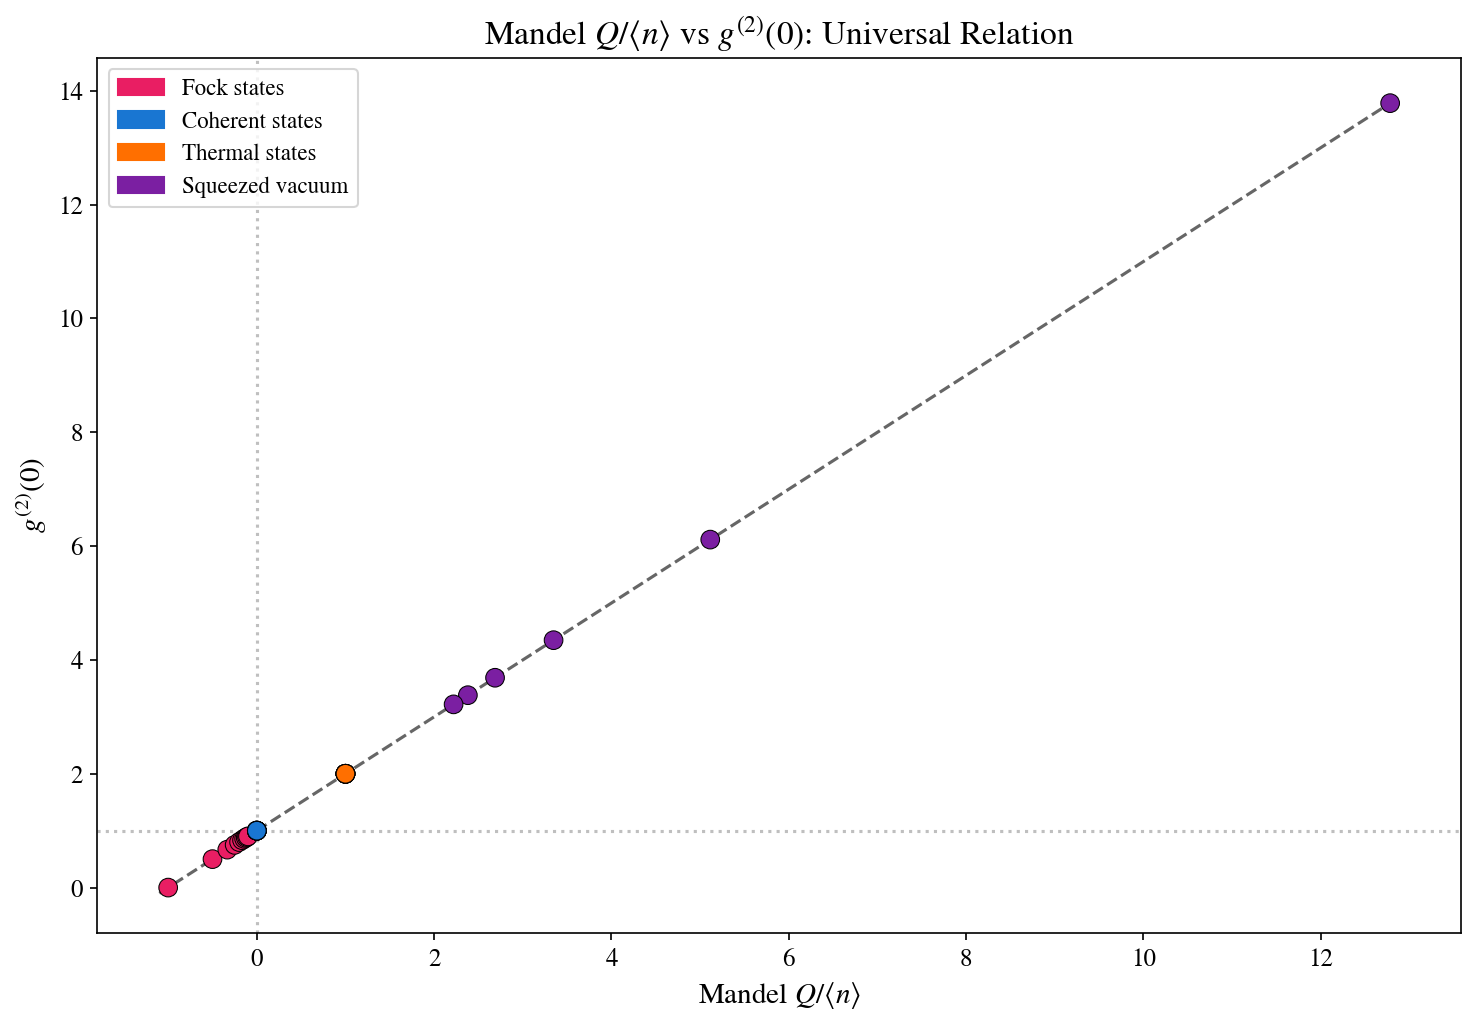

In [7]:
x_values = []
g2_scatter = []
colors_scatter = []

N_sc = 100
a_sc = qutip.destroy(N_sc)

# Fock states |1> through |10>
for n in range(1, 11):
    state = qutip.basis(N_sc, n)
    mn = mean_photon_number(state, a_sc)
    Q = mandel_Q(state, a_sc)
    x_values.append(Q / mn)
    g2_scatter.append(compute_g2_zero(state, a_sc))
    colors_scatter.append('#E91E63')

# Coherent states alpha = 0.5 to 4.0
for alpha in np.linspace(0.5, 4.0, 8):
    state = qutip.coherent(N_sc, alpha)
    mn = mean_photon_number(state, a_sc)
    Q = mandel_Q(state, a_sc)
    x_values.append(Q / mn)
    g2_scatter.append(compute_g2_zero(state, a_sc))
    colors_scatter.append('#1976D2')

# Thermal states n_bar = 0.5 to 5.0
for n_bar in np.linspace(0.5, 5.0, 8):
    state = qutip.thermal_dm(N_sc, n_bar)
    mn = mean_photon_number(state, a_sc)
    Q = mandel_Q(state, a_sc)
    x_values.append(Q / mn)
    g2_scatter.append(compute_g2_zero(state, a_sc))
    colors_scatter.append('#FF6F00')

# Squeezed vacuum r = 0.3 to 1.5
for r in np.linspace(0.3, 1.5, 6):
    state = qutip.squeeze(N_sc, r) * qutip.basis(N_sc, 0)
    mn = mean_photon_number(state, a_sc)
    Q = mandel_Q(state, a_sc)
    x_values.append(Q / mn)
    g2_scatter.append(compute_g2_zero(state, a_sc))
    colors_scatter.append('#7B1FA2')

fig, ax = plt.subplots(figsize=(10, 7))
ax.scatter(x_values, g2_scatter, c=colors_scatter, s=80, edgecolors='black',
           linewidth=0.5, zorder=3)

# Universal theoretical line
x_line = np.linspace(min(x_values) - 0.1, max(x_values) + 0.1, 200)
ax.plot(x_line, 1 + x_line, 'k--', alpha=0.6,
        label=r'$g^{(2)}(0) = 1 + Q/\langle n \rangle$')

ax.axhline(y=1, color='gray', linestyle=':', alpha=0.5)
ax.axvline(x=0, color='gray', linestyle=':', alpha=0.5)

legend_handles = [
    mpatches.Patch(color='#E91E63', label='Fock states'),
    mpatches.Patch(color='#1976D2', label='Coherent states'),
    mpatches.Patch(color='#FF6F00', label='Thermal states'),
    mpatches.Patch(color='#7B1FA2', label='Squeezed vacuum'),
]
ax.legend(handles=legend_handles, fontsize=11, loc='upper left')

ax.set_xlabel(r'Mandel $Q/\langle n \rangle$', fontsize=14)
ax.set_ylabel(r'$g^{(2)}(0)$', fontsize=14)
ax.set_title(r'Mandel $Q/\langle n \rangle$ vs $g^{(2)}(0)$: Universal Relation', fontsize=16)

plt.tight_layout()
plt.savefig(FIG_DIR / 'mandel_Q_vs_g2_scatter.png', bbox_inches='tight', dpi=300)
plt.savefig(FIG_DIR / 'mandel_Q_vs_g2_scatter.svg', bbox_inches='tight')
plt.show()

All 32 data points fall exactly on the universal line $g^{(2)}(0) = 1 + Q/\langle n \rangle$.
This identity is not an approximation — it is an exact operator identity relating
two photon-statistics diagnostics.

## In the lab

Photon statistics are measured with correlation experiments such as Hanbury
Brown-Twiss setups. A beamsplitter sends light to two detectors, and the
zero-delay coincidence rate gives access to $g^{(2)}(0)$. This is how thermal
bunching, coherent Poissonian statistics, and single-photon antibunching are
distinguished experimentally.

## Diagnostic summary

The useful structure in this notebook is the reduction of quantum states to
operator expectation values and compact statistical diagnostics. Here
$g^{(2)}(0)$, Mandel Q, and photon-number variance summarize different aspects
of photon statistics, but none of them uniquely determines the full quantum state.
